In [79]:
!pip install yfinance
!pip install pykalman

In [80]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from pykalman import KalmanFilter

## Pair Data Extraction and Preparation

In this step, we focus on a specific pair of assets: **Coca-Cola (KO)** and **PepsiCo (PEP)**. These companies operate in the same industry and are often considered suitable candidates for pair trading due to their similar economic drivers. Also we saw some good co-integration between them in the last 2-year window.

- Historical price data for both assets is downloaded using the `yfinance` library over the specified time period.
- From the downloaded dataset, only the **closing prices** are extracted, as they represent the final market value of each asset at the end of the trading day.
- The individual price series are then combined into a single DataFrame for easier analysis.
- Any missing values are removed to ensure proper alignment of the time series.

This processed dataset provides synchronized price data for the selected pair, which will be used for constructing the **spread**, estimating the **hedge ratio**, and generating trading signals.

In [81]:
ticker1 = 'KO'
ticker2 = 'PEP'
data1 = yf.download(ticker1,start = '2015-01-01',end = '2016-01-01')
data2 = yf.download(ticker2,start = '2015-01-01',end = '2016-01-01')
price1 = data1['Close'].iloc[:,0]
price2 = data2['Close'].iloc[:,0]
df = pd.DataFrame({
    "price1": price1,
    "price2": price2
})

df = df.dropna()

/tmp/ipykernel_36755/1318118699.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data1 = yf.download(ticker1,start = '2015-01-01',end = '2016-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_36755/1318118699.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data2 = yf.download(ticker2,start = '2015-01-01',end = '2016-01-01')
[*********************100%***********************]  1 of 1 completed


## ⚙️ Dynamic Hedge Ratio Estimation (Kalman Filter)

In this step, we estimate a **time-varying hedge ratio** between two assets using a Kalman Filter. Unlike traditional methods such as Ordinary Least Squares (OLS), which assume a constant relationship, the Kalman Filter allows the hedge ratio to evolve over time, making it more suitable for financial markets where relationships are dynamic.

---

### 🔹 Model Formulation

We model the relationship between the two asset prices as:

$$
p_{1,t} = \beta_t \cdot p_{2,t} + \alpha_t + \epsilon_t
$$

where:
- $p_{1,t}$ and $p_{2,t}$ are the (log) prices of the two assets  
- $\beta_t$ is the **time-varying hedge ratio**  
- $\alpha_t$ is the **intercept**  
- $\epsilon_t$ is the observation noise  

---

### 🔹 Log Transformation

We use the logarithm of prices to:
- stabilize variance  
- convert multiplicative relationships into additive ones  
- improve numerical stability for modeling  

---

### 🔹 State-Space Representation

The Kalman Filter expresses the model in state-space form:

**Observation Equation:**
$$
y_t = H_t x_t + \epsilon_t
$$

**State Equation:**
$$
x_t = x_{t-1} + w_t
$$

where:
- $y_t = p_{1,t}$  
- $x_t = [\beta_t, \alpha_t]^T$ (hidden state)  
- $H_t = [p_{2,t}, 1]$ (observation matrix)  
- $\epsilon_t$ = observation noise  
- $w_t$ = process noise  

---

### 🔹 Interpretation

- The hedge ratio $\beta_t$ and intercept $\alpha_t$ are treated as **latent variables** that evolve over time.
- The state equation assumes a **random walk**, meaning the relationship between the assets changes gradually rather than abruptly.
- The observation equation links the hidden state to the observed prices.

---

### 🔹 Key Design Choices

#### 1. Fixed Transition Covariance ($Q$)
The transition covariance matrix controls how much the hedge ratio is allowed to vary over time.

- A small fixed value is used to ensure **smooth evolution** of $\beta_t$  
- This prevents the model from overfitting short-term noise  

#### 2. Learned Observation Covariance ($R$)
The observation covariance represents the noise in the price relationship.

- It is estimated using the EM algorithm  
- This allows the model to adapt to the level of **market noise** present in the data  

---

### 🔹 Why This Approach

Financial relationships between assets are not constant—they change due to evolving market conditions, macroeconomic factors, and structural shifts. A static hedge ratio may fail to capture these dynamics.

The Kalman Filter provides:
- **Adaptive estimation** of the hedge ratio  
- **Robustness to noise**  
- A framework for **online updating** as new data arrives  

---

### 🔹 Output

The filter produces time series of:
- $\beta_t$ → dynamic hedge ratio  
- $\alpha_t$ → dynamic intercept  

These estimates are then used to construct the spread and generate trading signals.

---

### 🧠 Key Insight

> Instead of assuming a fixed relationship between assets, we continuously update our belief about their relationship as new information arrives.

This makes the strategy more responsive to changing market conditions and improves the reliability of the spread used in pair trading.



## 📊 Interpretation of Estimated Covariances (Q and R)

After initializing the Kalman Filter, we fix the transition covariance matrix ($Q$) and estimate the observation covariance ($R$) using the EM algorithm. The resulting values are:

$$
Q =
\begin{bmatrix}
0.0005 & 0 \\
0 & 0.0005
\end{bmatrix}
,\quad
R =
\begin{bmatrix}
0.00067895
\end{bmatrix}
$$

---

### 🔹 Transition Covariance ($Q$)

The matrix $Q$ controls how much the hidden state variables (i.e., the hedge ratio $\beta_t$ and intercept $\alpha_t$) are allowed to change over time.

- Since $Q$ is **small and fixed**, it implies:
  - The hedge ratio evolves **smoothly**
  - Sudden large changes in $\beta_t$ are discouraged
  - The model assumes that the relationship between the assets is **slowly varying**

In practical terms:
- A small $Q$ → stable and less noisy hedge ratio  
- A large $Q$ → highly reactive but potentially unstable estimates  

---

### 🔹 Observation Covariance ($R$)

The scalar $R$ represents the variance of the observation noise:

$$
\epsilon_t \sim \mathcal{N}(0, R)
$$

- It captures how much **noise or unexplained variation** exists in the relationship:
  
$$
p_{1,t} = \beta_t p_{2,t} + \alpha_t + \epsilon_t
$$

- The learned value:
  
$$
R = 0.00067895
$$

indicates the level of **market noise** in the spread.

---

### 🔹 Interpretation of the Result

- The fact that $R$ is of similar magnitude to $Q$ (but slightly larger) suggests:
  - There is **moderate noise** in the price relationship  
  - The model relies both on:
    - past estimates (controlled by $Q$)  
    - new observations (controlled by $R$)  

---

### 🔹 Kalman Filter Balance

The Kalman Filter works by balancing two sources of information:

- **Prediction (model belief)** → governed by $Q$  
- **Observation (new data)** → governed by $R$  

#### Key Insight:
- If $R$ is large → trust the model more  
- If $R$ is small → trust the data more  

In this case:
- $R$ is relatively small → the model places **reasonable trust in observed prices**, while still maintaining smoothness in the hedge ratio.

---

### 🧠 Final Insight

> The chosen $Q$ ensures a stable, slowly evolving hedge ratio, while the learned $R$ reflects the actual level of noise in the market data.

This balance allows the Kalman Filter to produce a **dynamic yet stable estimate** of the hedge ratio, which is crucial for constructing a reliable mean-reverting spread.

In [82]:
# 1. Use LOG prices
price_1 = np.log(price1.values)
price_2 = np.log(price2.values)

# 2. Observation Matrix H
obs_mat = np.vstack([price_2, np.ones(len(price_2))]).T[:, np.newaxis]

# 3. Initialize Kalman Filter
kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat,

    # Initial guess
    initial_state_mean=[0, 0],
    initial_state_covariance=np.eye(2) * 10,

    # FIXED Q (IMPORTANT)
    transition_covariance=np.eye(2) * 0.0005
)


# 4. Learn ONLY R using EM
kf = kf.em(price_1, n_iter=10, em_vars=['observation_covariance'])
R = kf.observation_covariance
Q = kf.transition_covariance

print("Fixed Q:\n", Q)
print("Learned R:\n", R)

# 5. Run Kalman Filter
state_means, state_covs = kf.filter(price_1)

beta = state_means[:, 0]
alpha = state_means[:, 1]


Fixed Q:
 [[0.0005 0.    ]
 [0.     0.0005]]
Learned R:
 [[0.00067895]]


## 📉 Dynamic Hedge Ratio Smoothing and Spread Construction

In this step, we use the estimated time-varying hedge ratio obtained from the Kalman Filter to construct the spread between the two assets.

First, the dynamic hedge ratio ($\beta_t$) is added to the dataset. Although the Kalman Filter provides a time-varying estimate, it may still contain short-term fluctuations due to market noise. To address this, we apply an **Exponential Weighted Moving Average (EWMA)** to smooth the hedge ratio. This ensures that recent observations are given more importance while reducing high-frequency noise, resulting in a more stable and reliable estimate.

Next, the intercept term ($\alpha_t$) is added to the dataset. This term captures any constant offset in the relationship between the two asset prices.

Finally, the spread is constructed as:

$$
\text{spread}_t = p_{1,t} - \beta_t \cdot p_{2,t}
$$

The spread represents the **relative deviation** between the two assets after accounting for their dynamic relationship. If the pair is cointegrated, this spread is expected to be **mean-reverting**, meaning that any large deviation from its equilibrium value is likely to be temporary.

This spread forms the core signal for the trading strategy, as it helps identify periods where the assets are relatively overvalued or undervalued with respect to each other.

In [83]:
df['beta'] = beta
df["beta"] = df['beta'].ewm(span=20).mean()
df['alpha'] = alpha
df['spread'] = df['price1'] - df['beta'] * df['price2']

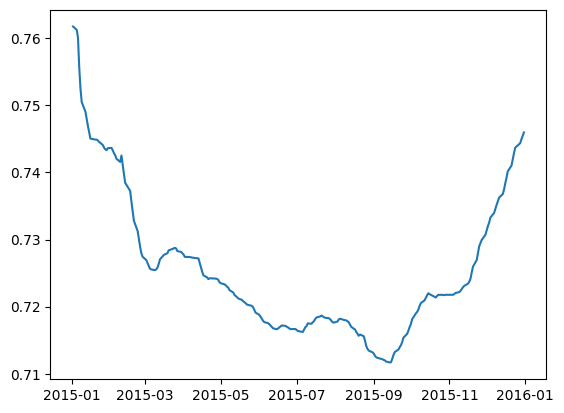

In [84]:
plt.plot(df['beta'])

## 📈 Visualizing the Hedge Relationship

In this step, we plot the actual price of the first asset alongside the **hedged price** of the second asset using the dynamic hedge ratio.

- The first line represents the price of the primary asset ($p_{1,t}$)
- The second line represents the scaled price of the second asset ($\beta_t \cdot p_{2,t}$)

By multiplying the second asset’s price with the time-varying hedge ratio, we align both series on a comparable scale.

---

### 🔹 Purpose of the Plot

This visualization helps us understand how well the dynamic hedge ratio captures the relationship between the two assets:

- If the two lines move closely together, it indicates a strong relationship  
- The hedge ratio is effectively adjusting the second asset to match the first  
- Deviations between the two lines correspond to the **spread**

---

### 🔹 Interpretation

- When the two lines overlap → assets are in equilibrium  
- When they diverge → temporary mispricing occurs  
- The gap between the lines is essentially the **tradable spread**

---

### 🧠 Key Insight

> The hedge ratio acts as a scaling factor that transforms one asset into another, allowing us to isolate their relative mispricing.

This plot provides a visual confirmation that the pair trading model is capturing a meaningful and stable relationship between the two assets.

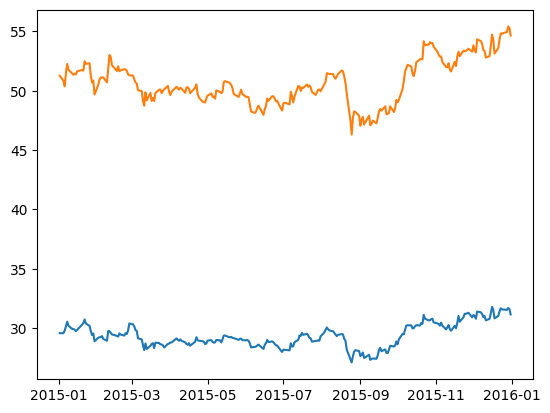

In [85]:
plt.plot(df["price1"])
plt.plot(df['beta'] * df["price2"])
plt.show()

## 📊 Rolling Statistics of the Spread

In this step, we compute the **rolling mean** and **rolling standard deviation** of the spread to capture its dynamic behavior over time.

- A rolling window of 60 periods is used to estimate local statistics of the spread.
- The rolling mean represents the **time-varying equilibrium level** of the spread.
- The rolling standard deviation measures the **volatility** of the spread around its mean.

```python
window = 60
df['spread_mean'] = df['spread'].rolling(window).mean()
df['spread_std'] = df['spread'].rolling(window).std()

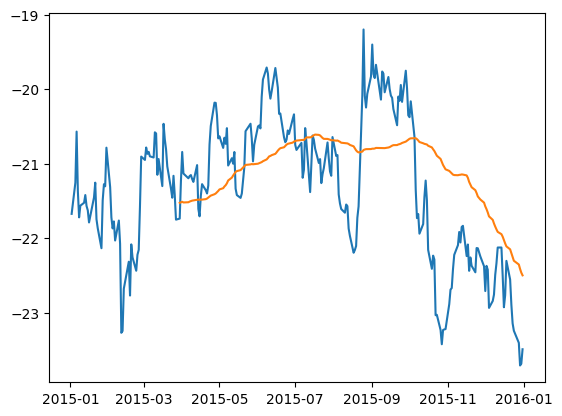

In [86]:
window = 60
df['spread_mean'] = df['spread'].rolling(window).mean()
df['spread_std'] = df['spread'].rolling(window).std()
plt.plot(df["spread"])
plt.plot(df["spread_mean"])
plt.show()

In [87]:
window = 60

df['spread_mean'] = df['spread'].rolling(window).mean()
df['spread_std'] = df['spread'].rolling(window).std()

df['zscore'] = (df['spread'] - df['spread_mean']) / df['spread_std']

entry_threshold = 1
exit_threshold = 0
df['long'] = df['zscore'] < -1
df['short'] = df['zscore'] > 1
df['exit'] = (df['zscore']*df['zscore'].shift(1)) < exit_threshold

position = 0
positions = []

for i in range(len(df)):

    if position == 0:
        if df['long'].iloc[i]:
            position = 1
        elif df['short'].iloc[i]:
            position = -1

    elif position == 1:
        if df['exit'].iloc[i]:
            position = 0

    elif position == -1:
        if df['exit'].iloc[i]:
            position = 0

    positions.append(position)

df['position'] = positions

## 📈 Z-Score Based Trading Strategy

In this step, we generate trading signals based on the standardized spread (z-score) and implement a simple rule-based trading strategy.

---

### 🔹 Rolling Statistics

We compute the rolling mean and standard deviation of the spread using a 60-day window:

- Rolling mean → dynamic equilibrium level  
- Rolling standard deviation → spread volatility  

These are used to standardize the spread.

---

### 🔹 Z-Score Calculation

The z-score is defined as:

$$
z_t = \frac{\text{spread}_t - \mu_t}{\sigma_t}
$$

where:
- $\mu_t$ = rolling mean  
- $\sigma_t$ = rolling standard deviation  

The z-score measures how many standard deviations the spread is away from its mean.

---

### 🔹 Trading Logic

We define simple threshold-based rules:

- **Long Position (Buy Spread)**:
  - When $z_t < -1$  
  - The spread is below its mean → asset 1 is undervalued relative to asset 2  

- **Short Position (Sell Spread)**:
  - When $z_t > 1$  
  - The spread is above its mean → asset 1 is overvalued  

- **Exit Position**:
  - When the z-score crosses zero  
  - Indicates the spread has reverted to its mean  

---

### 🔹 Position Management

We simulate trading using a position variable:

- `position = 1` → long spread  
- `position = -1` → short spread  
- `position = 0` → no position  

The strategy works as follows:

1. If no position is open:
   - Enter long or short based on z-score thresholds  

2. If a position is open:
   - Hold until the z-score crosses zero  
   - Exit when mean reversion occurs  

3. Positions are updated sequentially over time to simulate real trading behavior  

---

### 🔹 Why This Works

- The z-score standardizes the spread, making it easier to identify extreme deviations  
- Thresholds define statistically significant mispricings  
- The exit condition ensures trades are closed when the spread reverts  

---

### 🧠 Key Insight

> The strategy exploits temporary deviations from equilibrium by entering trades at extreme z-score levels and exiting when the spread returns to its mean.

This forms the foundation of a **mean-reversion trading strategy**, which is central to pair trading.

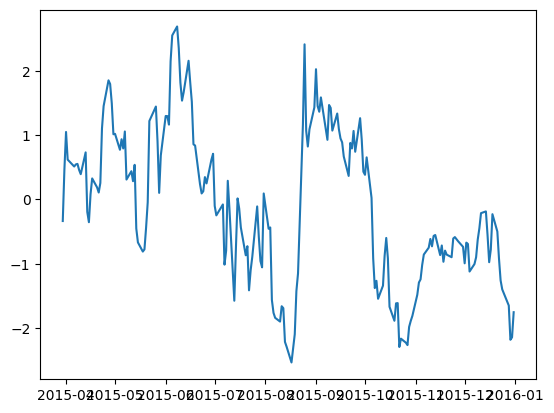

In [88]:
plt.plot(df["zscore"])

In [89]:
df['dP1'] = df['price1'].diff()
df['dP2'] = df['price2'].diff()

df['pnl'] = df['dP1'] - df['beta'].shift(1) * df['dP2']
df['capital'] = abs(df['price1']) + abs(df['beta'].shift(1) * df['price2'])
df['returns'] = df['pnl'] / df['capital']
df['strategy_returns'] = df['position'].shift(1) * df['returns']
df['cum_returns'] = (1 + df['strategy_returns']).cumprod()

sharpe = np.sqrt(252) * df['strategy_returns'].mean() / df['strategy_returns'].std()

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 2.0249964500099122


## 📊 Strategy Performance Evaluation

In this step, we evaluate the performance of the pair trading strategy by computing the profit and loss (PnL), returns, cumulative returns, and the Sharpe ratio.

---

### 🔹 Profit and Loss (PnL)

We first compute the daily price changes for both assets:

- $dP_1$ = change in price of asset 1  
- $dP_2$ = change in price of asset 2  

The PnL is calculated as:

$$
\text{PnL}_t = dP_{1,t} - \beta_{t-1} \cdot dP_{2,t}
$$

This represents the profit from holding a **long position in asset 1** and a **short position in asset 2**, scaled by the hedge ratio.

---

### 🔹 Capital Allocation

The capital required for the trade is approximated as:

$$
\text{Capital}_t = |p_{1,t}| + |\beta_{t-1} \cdot p_{2,t}|
$$

This reflects the total exposure from both long and short positions.

---

### 🔹 Returns

The daily return is computed as:

$$
\text{Return}_t = \frac{\text{PnL}_t}{\text{Capital}_t}
$$

To ensure realistic trading, the strategy return is based on the **previous day’s position**:

$$
\text{Strategy Return}_t = \text{Position}_{t-1} \cdot \text{Return}_t
$$

This avoids look-ahead bias and ensures that trades are executed using available information.

---

### 🔹 Cumulative Returns

The cumulative performance of the strategy is calculated as:

$$
\text{Cumulative Returns}_t = \prod (1 + \text{Strategy Return}_t)
$$

This represents the growth of capital over time.

---

### 🔹 Sharpe Ratio

The Sharpe ratio is used to measure the risk-adjusted performance of the strategy:

$$
\text{Sharpe Ratio} = \sqrt{252} \cdot \frac{\mathbb{E}[R]}{\sigma(R)}
$$

where:
- $\mathbb{E}[R]$ = average daily return  
- $\sigma(R)$ = standard deviation of returns  
- 252 = number of trading days in a year  

A higher Sharpe ratio indicates better risk-adjusted returns.

---

### 🧠 Key Insight

> This step translates trading signals into actual financial performance, allowing us to evaluate both profitability and risk of the strategy.

The results obtained here form the basis for comparing the effectiveness of the strategy, both with and without transaction costs.

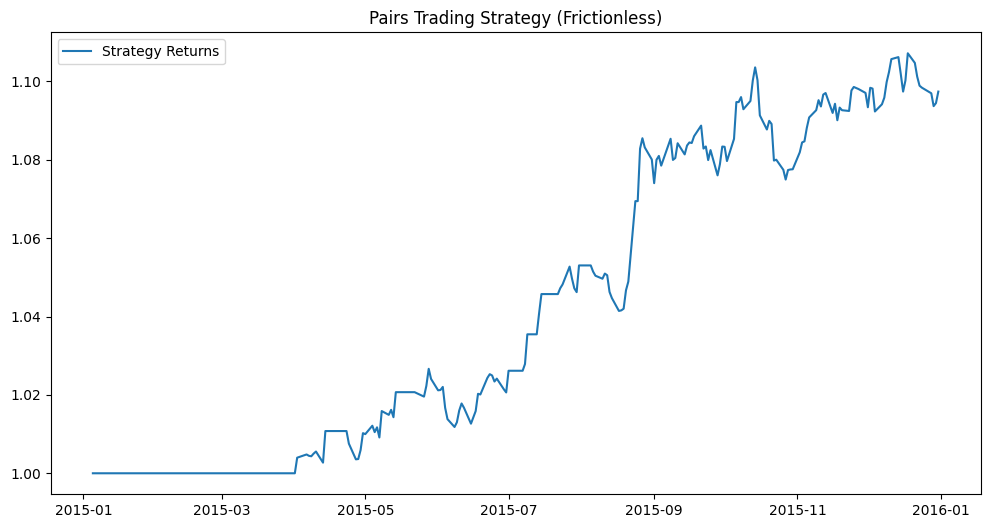

In [90]:
plt.figure(figsize=(12,6))
plt.plot(df['cum_returns'], label='Strategy Returns')
plt.legend()
plt.title("Pairs Trading Strategy (Frictionless)")
plt.show()

In [91]:
# --- Transaction Cost Parameters ---
cost_per_trade = 0.001  # 0.1% per trade (adjust if needed)

# --- Identify trades (change in position) ---
df['trade'] = df['position'].diff().abs()

# --- Transaction cost incurred when position changes ---
df['transaction_cost'] = cost_per_trade * df['trade']

# --- Adjust strategy returns for transaction cost ---
df['strategy_returns_tc'] = df['strategy_returns'] - df['transaction_cost']

# --- Cumulative returns with transaction costs ---
df['cum_returns_tc'] = (1 + df['strategy_returns_tc']).cumprod()

# --- Sharpe ratio with transaction costs ---
sharpe_tc = np.sqrt(252) * df['strategy_returns_tc'].mean() / df['strategy_returns_tc'].std()

print("Sharpe Ratio (with transaction costs):", sharpe_tc)

Sharpe Ratio (with transaction costs): 1.7006613395182277


## 💸 Transaction Costs

In this step, we incorporate transaction costs to make the strategy more realistic. A fixed cost is applied whenever the position changes, capturing trading expenses such as brokerage fees and bid-ask spread.

Trades are identified using changes in position, and the corresponding cost is subtracted from the strategy returns. The cumulative returns and Sharpe ratio are then recomputed using these adjusted returns.

This allows us to evaluate how robust the strategy remains after accounting for real-world trading frictions.